# Step 7: Read the Record
In this notebook, we will explore the raw MIT-BIH dataset by loading a single record (`100.dat`) and plotting it.

In [ ]:
import os
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# Point to the raw data directory
DATA_DIR = '../data/raw/'
RECORD_NAME = '100'

# Read the record and annotations
record = wfdb.rdrecord(os.path.join(DATA_DIR, RECORD_NAME))
annotation = wfdb.rdann(os.path.join(DATA_DIR, RECORD_NAME), 'atr')

# Extract the signal (MLII channel is usually channel 0)
signal = record.p_signal[:, 0]

print(f"Sampling Frequency: {record.fs} Hz")
print(f"Total signal length: {len(signal)} samples")

# Plot the first 3 seconds of the raw signal (360 Hz * 3 = 1080 samples)
plt.figure(figsize=(12, 4))
plt.plot(signal[:1080])
plt.title(f"Raw ECG Signal - Record {RECORD_NAME} (First 3 seconds)")
plt.xlabel("Samples")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

---
# Step 8: Filter the Signal
Raw ECG data contains noise, specifically **baseline wander** (low-frequency drift caused by the patient breathing) and **powerline interference** (high-frequency static from the electrical wall outlet).

We use a **Bandpass Filter** to remove these. We tell the math to only let frequencies between `0.5 Hz` and `45 Hz` pass through. Anything lower (breathing) or higher (static) gets erased!

In [ ]:
from scipy.signal import butter, filtfilt

def apply_bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360.0, order=2):
    """Applies a Butterworth bandpass filter to the ECG signal."""
    nyq = 0.5 * fs # Nyquist frequency (half the sampling rate)
    low = lowcut / nyq
    high = highcut / nyq
    # Create the filter
    b, a = butter(order, [low, high], btype='band')
    # Apply the filter to the data forwards and backwards to prevent phase shift
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# Apply the filter to our signal
filtered_signal = apply_bandpass_filter(signal)

# Plot the Raw vs Filtered signal to see the difference!
plt.figure(figsize=(12, 6))

# Plot Raw in transparent red
plt.plot(signal[:1080], label='Raw Noisy Signal', alpha=0.5, color='red')

# Plot Filtered in solid blue
plt.plot(filtered_signal[:1080], label='Clean Filtered Signal', color='blue', linewidth=1.5)

plt.title("Step 8: Noise Filtering Comparison")
plt.xlabel("Samples")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)
plt.show()

---
# Step 9: Find R-Peaks
An R-peak is the tall, sharp spike in the heartbeat. To train our AI, we need to know exactly where these peaks are so we can center our "slices" around them.

Normally, we would have to write a complex math algorithm to detect these peaks. However, because we are using the gold-standard MIT-BIH dataset, **expert cardiologists have already found and labeled every single peak for us!** These labels are stored in the `.atr` annotation file we loaded back in Step 7.

Let's grab those exact timestamps and plot them as red dots on our clean signal.

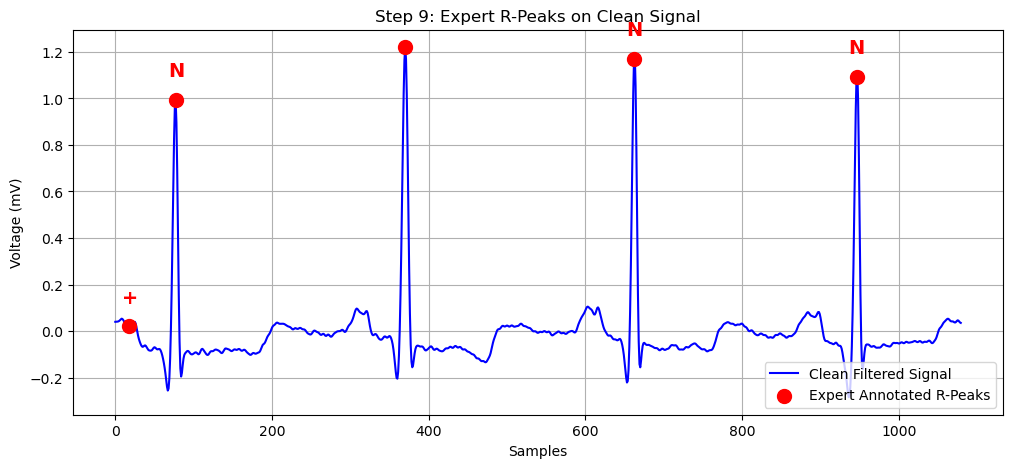

In [4]:
peaks_in_window = []
symbols_in_window = []

# Find all annotations that happen within our 3-second window (first 1080 samples)
for idx, sym in zip(annotation.sample, annotation.symbol):
    if idx < 1080:
        peaks_in_window.append(idx)
        symbols_in_window.append(sym)
    elif idx >= 1080:
        break # Stop searching once we pass our window

# Get the voltage of the filtered signal at those exact peak locations
peak_voltages = [filtered_signal[i] for i in peaks_in_window]

plt.figure(figsize=(12, 5))
plt.plot(filtered_signal[:1080], label='Clean Filtered Signal', color='blue')

# Plot the peaks as large red dots
plt.scatter(peaks_in_window, peak_voltages, color='red', s=100, label='Expert Annotated R-Peaks', zorder=5)

# Add the text label (e.g., 'N' for Normal) slightly above each red dot
for i, txt in enumerate(symbols_in_window):
    plt.annotate(txt, (peaks_in_window[i]-10, peak_voltages[i] + 0.1), fontsize=14, color='red', weight='bold')

plt.title("Step 9: Expert R-Peaks on Clean Signal")
plt.xlabel("Samples")
plt.ylabel("Voltage (mV)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()